# Machine Learning-Based Classification of Shoulder Implant X-Rays for Manufacturer Identification

In [1]:
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io, transform
from sklearn import preprocessing
import joblib
import cv2
from imblearn.over_sampling import SMOTE

SyntaxError: invalid syntax (_metadata_requests.py, line 1512)

In [2]:
path = r"Data"
model_folder = "model"
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
categories


['Cofield.jpg', 'Depuy.jpg', 'tornier.jpg', 'Zimmer.jpg']

In [3]:
X_file = os.path.join(model_folder, "X.txt.npy")
Y_file = os.path.join(model_folder, "Y.txt.npy")
if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print("X and Y arrays loaded successfully.")
else:
    X = [] # input array
    Y = [] # output array
    for root, dirs, directory in os.walk(path):
        for j in range(len(directory)):
            name = os.path.basename(root)
            print(f'Loading category: {dirs}')
            print(name+" "+root+"/"+directory[j])
            if 'Thumbs.db' not in directory[j]:
                img_array = cv2.imread(root+"/"+directory[j])
                img_resized = resize(img_array, (64, 64, 3))
                # Append the input image array to X
                X.append(img_resized.flatten())
                # Append the index of the category in categories list to Y
                Y.append(categories.index(name))
    X = np.array(X)
    Y = np.array(Y)
    np.save(X_file, X)
    np.save(Y_file, Y)

X and Y arrays loaded successfully.


<AxesSubplot:ylabel='count'>

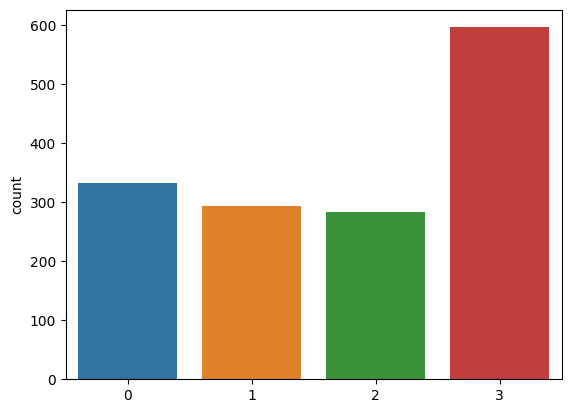

In [4]:
sns.countplot(x=Y)

In [6]:
from imblearn.over_sampling import SMOTE

In [7]:
sm = SMOTE(random_state = 2) 
X, Y = sm.fit_resample(X, Y)

<AxesSubplot:ylabel='count'>

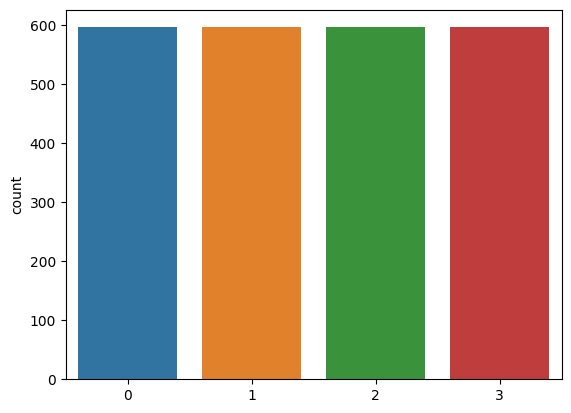

In [8]:
sns.countplot(x=Y)

In [9]:
# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.30,random_state=77)

In [10]:
labels=categories

In [11]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []